# 해설 문서 「교역 네트워크를 읽는 지표」 — 분석 파이썬 코드

이 노트북은 해설 문서(`paper.md`)의 그림 두 장과 본문에 인용한 수치를 만든다. 저장소 안 어느 폴더에서 열어도 되며, 루트의 `config/settings.py`를 찾아 경로를 잡는다.

입력은 둘이다. `scripts/01`~`04`가 만든 DuckDB (`data/processed/baci_net.duckdb`)의 네트워크 지표 표 `mart_net_metrics`, 그리고 `scripts/10_export_network_json.py`가 만든 컴퓨터(HS 8471) 품목 파일 `data/interim/network/8471.json`이다. 그림은 이 폴더의 `img/`에 저장된다.

In [1]:
import sys, json, random
from pathlib import Path
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
from IPython.display import display

# 저장소 루트를 찾는다. 이 노트북은 저장소 안 어느 폴더에서 열어도 된다.
ROOT = Path.cwd().resolve()
while not (ROOT / "config" / "settings.py").exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError("저장소 루트(config/settings.py)를 찾지 못했다")
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from config.settings import DB_PATH

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
REGION_HEX = {"Asia": "#2F7FD1", "America": "#2A8F55", "Middle East": "#8F62D8", "Europe": "#B8862A",
              "Oceania": "#1F9C90", "Africa": "#C95A4B", "Other": "#7C8593"}
REGION_KO = {"Asia": "아시아", "America": "아메리카", "Middle East": "중동", "Europe": "유럽", "Oceania": "오세아니아", "Africa": "아프리카"}
con = duckdb.connect(str(DB_PATH), read_only=True)

import igraph as ig
import leidenalg as la

HERE = ROOT / "analysis" / "network-theory"
IMG = HERE / "img"
IMG.mkdir(exist_ok=True)
print("저장소:", ROOT)
print("DB:", DB_PATH, "있음" if DB_PATH.exists() else "없음")

저장소: C:\Work\Projects\UNComtraade
DB: C:\Work\Projects\UNComtraade\data\processed\baci_net.duckdb 있음


## 1. 지표 함수

`scripts/04_compute_metrics.py`와 같은 정의로 밀도(density), 나가는 차수 중심화(out-degree centralization), 수출 HHI, 평균 군집계수(clustering coefficient), 모듈성(modularity, Leiden), 최대 $`k`$-코어($`k`$-core)를 계산한다.

In [2]:
def metrics(g):
    """g: 방향 가중 그래프(igraph). 04_compute_metrics와 같은 정의."""
    n = g.vcount(); m = g.ecount()
    outd = np.array(g.degree(mode="out"))
    outs = np.array(g.strength(mode="out", weights="weight"))
    p = outs / outs.sum()
    gu = g.as_undirected(mode="collapse", combine_edges="sum")
    part = la.find_partition(gu, la.ModularityVertexPartition, weights="weight", seed=0)
    return dict(밀도=m / (n * (n - 1)),
                중심화=float((outd.max() - outd).sum() / ((n - 1) ** 2)),
                HHI=float((p ** 2).sum()),
                군집=float(gu.transitivity_avglocal_undirected(mode="zero")),
                모듈성=float(part.quality()),
                최대_k코어=int(max(gu.coreness())),
                공동체_수=len(part))


def toy(edges, n):
    g = ig.Graph(n=n, edges=edges, directed=True)
    g.es["weight"] = [1.0] * g.ecount()
    return g


def normalize(xy):
    """배치 좌표를 가운데로 옮기고 가장 먼 점이 1이 되게 줄인다. 네 칸이 같은 틀을 쓰게 한다."""
    xy = np.asarray(xy, float)
    xy = xy - (xy.max(0) + xy.min(0)) / 2
    return xy / np.abs(xy).max()

## 2. 그림 1 — 네 가지 전형 구조

나라가 12개인 작은 방향 그래프 넷을 만들고 위 함수로 지표를 계산한다. (가) 한 나라가 나머지 모두에게 수출, (나) 모두가 이웃 둘에게 수출, (다) 두 블록이 선 하나로 이어짐, (라) 서로 모두 거래하는 5개국 핵심에 주변국이 하나씩 붙음.

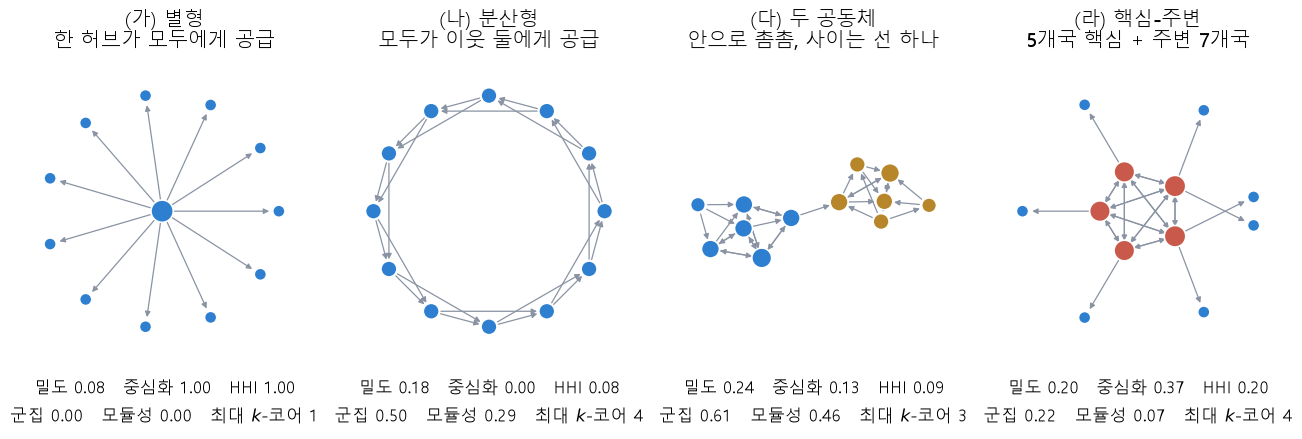

,밀도,중심화,HHI,군집,모듈성,최대_k코어,공동체_수
(가) 별형,0.083,1.000,1.000,0.000,0.000,1.0,1.0
(나) 분산형,0.182,0.000,0.083,0.500,0.292,4.0,3.0
(다) 두 공동체,0.242,0.132,0.090,0.614,0.464,3.0,2.0
(라) 핵심-주변,0.205,0.372,0.202,0.217,0.074,4.0,3.0


In [3]:
n = 12
star = toy([(0, j) for j in range(1, n)], n)
rng = np.random.default_rng(3)
disp = toy([(i, (i + k) % n) for i in range(n) for k in (1, 2)], n)
a, b = list(range(6)), list(range(6, 12))
comm = toy([(i, j) for grp in (a, b) for i in grp for j in grp if i != j and rng.random() < 0.55] + [(5, 6)], n)
core = toy([(i, j) for i in range(5) for j in range(5) if i != j] + [(i % 5, i) for i in range(5, 12)], n)
panels = [("(가) 별형", star, "한 허브가 모두에게 공급", "star"), ("(나) 분산형", disp, "모두가 이웃 둘에게 공급", "circle"),
          ("(다) 두 공동체", comm, "안으로 촘촘, 사이는 선 하나", "kk"), ("(라) 핵심-주변", core, "5개국 핵심 + 주변 7개국", "kk")]

fig, axes = plt.subplots(1, 4, figsize=(13, 4.9))
vals = {}
for ax, (title, g, sub, how) in zip(axes, panels):
    mt = metrics(g); vals[title] = mt
    lay = g.layout_star(center=0) if how == "star" else (g.layout_circle() if how == "circle" else g.layout("kk"))
    xy = normalize(lay.coords)
    for e in g.es:
        s, t = e.tuple
        ax.annotate("", xy=xy[t], xytext=xy[s],
                    arrowprops=dict(arrowstyle="-|>", color="#8A93A3", lw=0.9, shrinkA=7, shrinkB=7, mutation_scale=8))
    deg = np.array(g.degree(mode="all"))
    if "공동체" in title:
        cols = ["#2F7FD1" if v < 6 else "#B8862A" for v in range(n)]
    elif "핵심" in title:
        cols = ["#C95A4B" if v < 5 else "#2F7FD1" for v in range(n)]
    else:
        cols = ["#2F7FD1"] * n
    ax.scatter(xy[:, 0], xy[:, 1], s=60 + 18 * deg, c=cols, edgecolors="white", linewidths=1.2, zorder=3)
    ax.set_title(f"{title}\n{sub}", fontsize=14.5, pad=10)
    ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3); ax.set_aspect("equal"); ax.axis("off")
    ax.text(0.5, -0.04, f"밀도 {mt['밀도']:.2f}   중심화 {mt['중심화']:.2f}   HHI {mt['HHI']:.2f}\n"
                        f"군집 {mt['군집']:.2f}   모듈성 {mt['모듈성']:.2f}   최대 $k$-코어 {mt['최대_k코어']}",
            transform=ax.transAxes, ha="center", va="top", fontsize=12.5, linespacing=1.6)
fig.subplots_adjust(left=0.01, right=0.99, top=0.83, bottom=0.2, wspace=0.08)
fig.savefig(IMG / "fig1_archetypes.png", dpi=300, facecolor="white")
plt.show()
pd.DataFrame(vals).T.round(3)

## 3. 그림 2 — 컴퓨터(HS 8471), 1995년과 2024년

각 수입국을 그해 1위 공급국에만 잇는다. 어느 1위 공급선에도 닿지 않는 나라는 그리지 않는다. 그림 아래 지표는 줄이기 전의 전체 그래프(고정 207개국, 100만 달러 이상 흐름)에서 계산한 `mart_net_metrics` 값이다. 이름표는 큰 나라부터 위·아래·오른쪽·왼쪽 가운데 이미 붙인 이름표와 겹치지 않는 자리에 붙인다.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


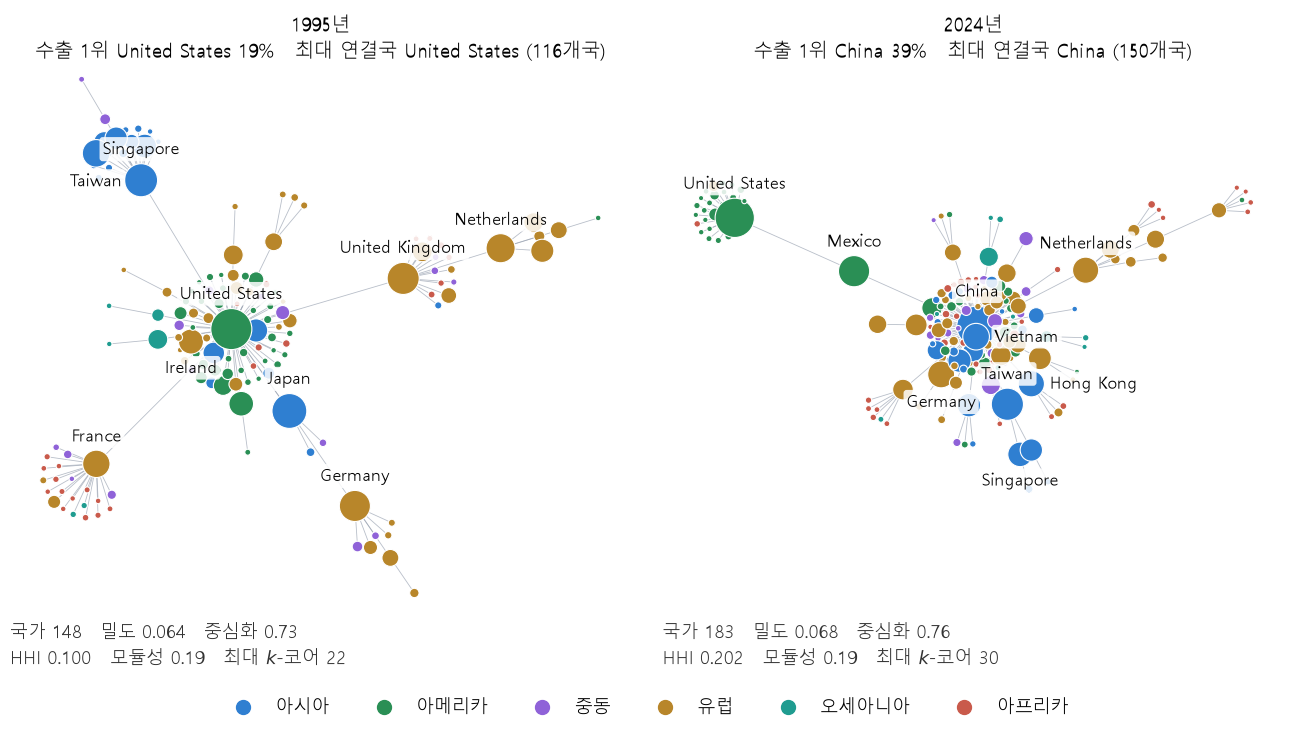

,1995,2024
수출1위,United States,China
점유율,0.185,0.39
최대연결국,United States,China
상대국수,116,150
국가,148,183
밀도,0.064,0.068
중심화,0.73,0.76
HHI,0.1,0.202
모듈성,0.19,0.191
최대_k코어,22,30


In [4]:
def place_labels(ax, fig, xy, radius_pt, names, order):
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    placed = []
    for k in order:
        r = radius_pt[k] + 2.5
        best, best_ov, best_bb = None, None, None
        for dx, dy, ha, va in [(0, r, "center", "bottom"), (0, -r, "center", "top"), (r, 0, "left", "center"), (-r, 0, "right", "center")]:
            t = ax.annotate(names[k], xy=xy[k], xytext=(dx, dy), textcoords="offset points", ha=ha, va=va, fontsize=12.5, zorder=5,
                            bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.85))
            bb = t.get_window_extent(renderer).expanded(1.04, 1.1)
            ov = sum(max(0, min(bb.x1, p.x1) - max(bb.x0, p.x0)) * max(0, min(bb.y1, p.y1) - max(bb.y0, p.y0)) for p in placed)
            if best is None or ov < best_ov:
                if best is not None:
                    best.remove()
                best, best_ov, best_bb = t, ov, bb
            else:
                t.remove()
            if ov == 0:
                break
        placed.append(best_bb)


raw = json.loads((ROOT / "data" / "interim" / "network" / "8471.json").read_text(encoding="utf-8"))
mt = {int(r[0]): r[1:] for r in con.execute("""SELECT t, n_nodes, density, centralization_out, hhi_exp, modularity, max_kcore
    FROM mart_net_metrics WHERE level='hs4' AND code='8471' AND variant='w1m_bal' AND t IN (1995, 2024)""").fetchall()}
fig, axes = plt.subplots(1, 2, figsize=(13, 7.4))
info = {}
for ax, year in zip(axes, (1995, 2024)):
    d = raw["years"][str(year)]
    all_nodes = d["n"]; total = d["total"]
    top = max(all_nodes, key=lambda x: x[3]); hub = max(all_nodes, key=lambda x: x[5])
    e1 = [(e[0], e[1]) for e in d["e"] if e[3] == 1]
    keep = sorted({c for pair in e1 for c in pair})
    byid = {x[0]: x for x in all_nodes}
    nodes = [byid[c] for c in keep]; idx = {c: k for k, c in enumerate(keep)}
    el = [(idx[s], idx[t]) for s, t in e1]
    g = ig.Graph(n=len(nodes), edges=el, directed=True)
    seed = np.random.default_rng(7).random((len(nodes), 2)).tolist()
    random.seed(7)  # igraph의 배치 난수원은 파이썬 random 모듈이다
    xy = np.array(g.layout_fruchterman_reingold(niter=2000, seed=seed).coords)
    size = np.array([x[3] + x[4] for x in nodes], float)
    for s, t in el:
        ax.plot([xy[s, 0], xy[t, 0]], [xy[s, 1], xy[t, 1]], color="#9AA3B2", lw=0.6, alpha=0.7, zorder=1)
    area = 12 + 1300 * np.sqrt(size / total)
    cols = [REGION_HEX.get(x[2], REGION_HEX["Other"]) for x in nodes]
    ax.scatter(xy[:, 0], xy[:, 1], s=area, c=cols, edgecolors="white", linewidths=0.8, zorder=2)
    pad = 0.06 * (xy.max(0) - xy.min(0))
    ax.set_xlim(xy[:, 0].min() - pad[0], xy[:, 0].max() + pad[0]); ax.set_ylim(xy[:, 1].min() - pad[1], xy[:, 1].max() + pad[1])
    ax.set_aspect("equal", adjustable="datalim"); ax.axis("off")
    n_nodes, dens, cen, hhi, mod, kc = mt[year]
    info[year] = dict(수출1위=top[1], 점유율=round(top[3] / total, 3), 최대연결국=hub[1], 상대국수=hub[5], 국가=n_nodes,
                      밀도=round(dens, 3), 중심화=round(cen, 3), HHI=round(hhi, 3), 모듈성=round(mod, 3), 최대_k코어=kc,
                      그린_나라=len(nodes), 뺀_고립국=len(all_nodes) - len(nodes))
    ax.set_title(f"{year}년\n수출 1위 {top[1]} {100 * top[3] / total:.0f}%   최대 연결국 {hub[1]} ({hub[5]}개국)", fontsize=14, linespacing=1.4)
    ax.text(0.0, -0.02, f"국가 {n_nodes}   밀도 {dens:.3f}   중심화 {cen:.2f}\nHHI {hhi:.3f}   모듈성 {mod:.2f}   최대 $k$-코어 {kc}",
            transform=ax.transAxes, fontsize=13, color="#333", va="top", linespacing=1.5)
    order = list(np.argsort(-size)[:9])
    place_labels(ax, fig, xy, np.sqrt(area / np.pi), [x[1] for x in nodes], order)
handles = [plt.Line2D([], [], marker="o", ls="", color=REGION_HEX[k], markersize=10, label=v) for k, v in REGION_KO.items()]
fig.legend(handles=handles, loc="lower center", ncol=6, frameon=False, fontsize=13)
fig.subplots_adjust(left=0.01, right=0.99, top=0.9, bottom=0.17, wspace=0.05)
fig.savefig(IMG / "fig2_computers_1995_2024.png", dpi=300, facecolor="white")
plt.show()
pd.DataFrame(info)

## 4. 본문 인용 수치 — 동류성

§5의 동류성(assortativity) 절이 인용한 값이다. HS4 호 전체의 중위값과 컴퓨터(HS 8471)의 값, 고정 207개국·100만 달러 이상 흐름.

In [5]:
a1 = con.execute("""SELECT t, median(assortativity_deg) AS HS4_호_중위 FROM mart_net_metrics
    WHERE level='hs4' AND variant='w1m_bal' AND t IN (1995, 2024) GROUP BY t ORDER BY t""").df().set_index("t")
a2 = con.execute("""SELECT t, assortativity_deg AS 컴퓨터_8471 FROM mart_net_metrics
    WHERE level='hs4' AND code='8471' AND variant='w1m_bal' AND t IN (1995, 2024) ORDER BY t""").df().set_index("t")
a1.join(a2).round(3)

,HS4_호_중위,컴퓨터_8471
t,,
1995,-0.409,-0.548
2024,-0.409,-0.493
